# Todo REST API Performance Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

output_dir = Path('performance_graphs')
output_dir.mkdir(exist_ok=True)

## 1. Load Performance Data

In [2]:
results_dir = Path('performance-unit-tests/target/performance-results')

todo_df = pd.read_csv(results_dir / 'todo_performance_results.csv')
category_df = pd.read_csv(results_dir / 'category_performance_results.csv')
project_df = pd.read_csv(results_dir / 'project_performance_results.csv')
relationship_df = pd.read_csv(results_dir / 'relationship_performance_results.csv')

todo_df['Entity'] = 'Todo'
category_df['Entity'] = 'Category'
project_df['Entity'] = 'Project'
relationship_df['Entity'] = 'Relationship'

all_data = pd.concat([todo_df, category_df, project_df, relationship_df], ignore_index=True)

print(f"\nTotal records: {len(all_data)}")
print(f"\nColumns: {list(all_data.columns)}")
all_data.head()


Total records: 74

Columns: ['TestName', 'ObjectCount', 'OperationType', 'AverageTimeMs', 'MinTimeMs', 'MaxTimeMs', 'MedianTimeMs', 'TotalTimeMs', 'SampleCount', 'Timestamp', 'Entity']


,TestName,ObjectCount,OperationType,AverageTimeMs,MinTimeMs,MaxTimeMs,MedianTimeMs,TotalTimeMs,SampleCount,Timestamp,Entity
0,TodoCreate,10,CREATE,4.781,3.946,7.461,4.733,47.806,10,Sun Nov 30 18:23:49 EST 2025,Todo
1,TodoCreate,25,CREATE,4.328,3.723,7.090,4.132,108.191,25,Sun Nov 30 18:23:49 EST 2025,Todo
2,TodoCreate,50,CREATE,4.196,3.524,7.801,4.027,209.795,50,Sun Nov 30 18:23:49 EST 2025,Todo
3,TodoCreate,100,CREATE,4.255,3.628,9.611,4.147,425.475,100,Sun Nov 30 18:23:49 EST 2025,Todo
4,TodoCreate,250,CREATE,4.603,3.567,12.858,4.262,1150.743,250,Sun Nov 30 18:23:49 EST 2025,Todo


## 2. Basic Performance Analysis: Average Time vs Object Count

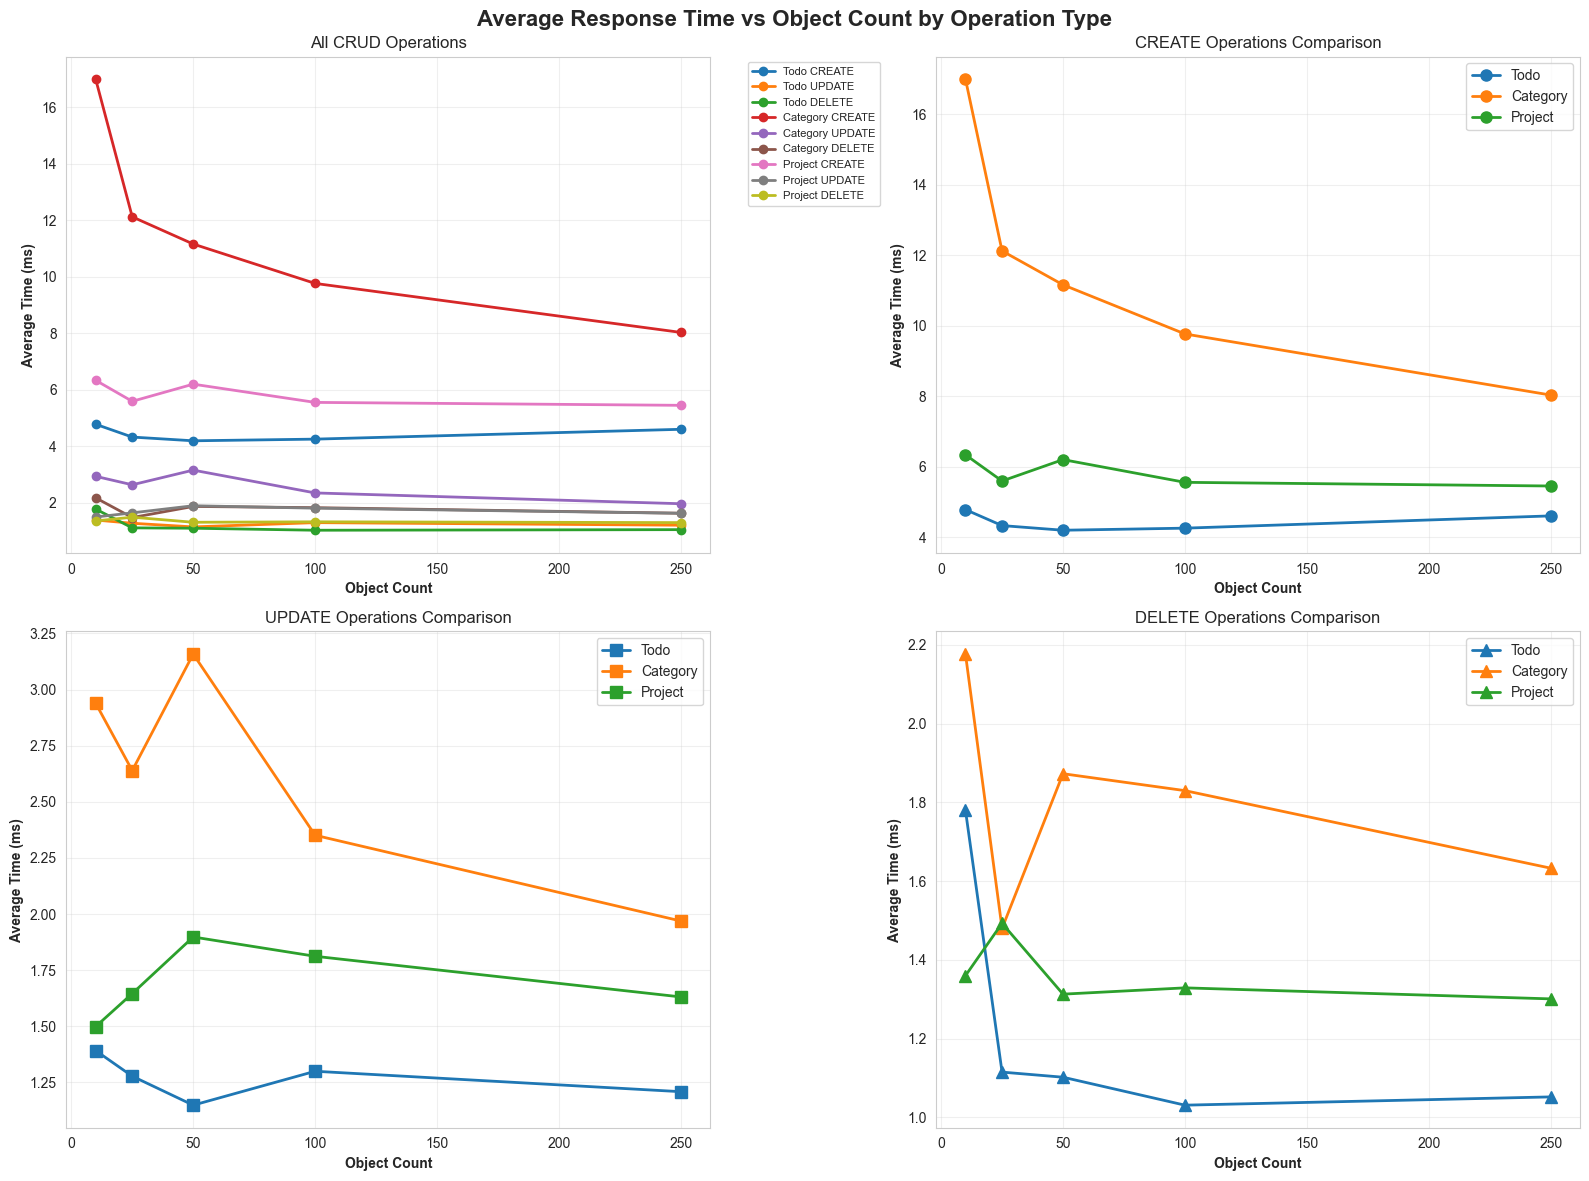

In [3]:
crud_ops = all_data[all_data['OperationType'].isin(['CREATE', 'UPDATE', 'DELETE'])]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Average Response Time vs Object Count by Operation Type', fontsize=16, fontweight='bold')

operations = ['CREATE', 'UPDATE', 'DELETE']
entities = ['Todo', 'Category', 'Project']

# Plot 1: All CRUD operations together
ax = axes[0, 0]
for entity in entities:
    entity_data = crud_ops[crud_ops['Entity'] == entity]
    for op in operations:
        op_data = entity_data[entity_data['OperationType'] == op]
        ax.plot(op_data['ObjectCount'], op_data['AverageTimeMs'], 
                marker='o', label=f'{entity} {op}', linewidth=2)

ax.set_xlabel('Object Count', fontweight='bold')
ax.set_ylabel('Average Time (ms)', fontweight='bold')
ax.set_title('All CRUD Operations')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: CREATE operations only
ax = axes[0, 1]
for entity in entities:
    entity_data = crud_ops[(crud_ops['Entity'] == entity) & (crud_ops['OperationType'] == 'CREATE')]
    ax.plot(entity_data['ObjectCount'], entity_data['AverageTimeMs'], 
            marker='o', label=entity, linewidth=2, markersize=8)

ax.set_xlabel('Object Count', fontweight='bold')
ax.set_ylabel('Average Time (ms)', fontweight='bold')
ax.set_title('CREATE Operations Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: UPDATE operations only
ax = axes[1, 0]
for entity in entities:
    entity_data = crud_ops[(crud_ops['Entity'] == entity) & (crud_ops['OperationType'] == 'UPDATE')]
    ax.plot(entity_data['ObjectCount'], entity_data['AverageTimeMs'], 
            marker='s', label=entity, linewidth=2, markersize=8)

ax.set_xlabel('Object Count', fontweight='bold')
ax.set_ylabel('Average Time (ms)', fontweight='bold')
ax.set_title('UPDATE Operations Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: DELETE operations only
ax = axes[1, 1]
for entity in entities:
    entity_data = crud_ops[(crud_ops['Entity'] == entity) & (crud_ops['OperationType'] == 'DELETE')]
    ax.plot(entity_data['ObjectCount'], entity_data['AverageTimeMs'], 
            marker='^', label=entity, linewidth=2, markersize=8)

ax.set_xlabel('Object Count', fontweight='bold')
ax.set_ylabel('Average Time (ms)', fontweight='bold')
ax.set_title('DELETE Operations Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'crud_operations_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Relationship Operations Performance

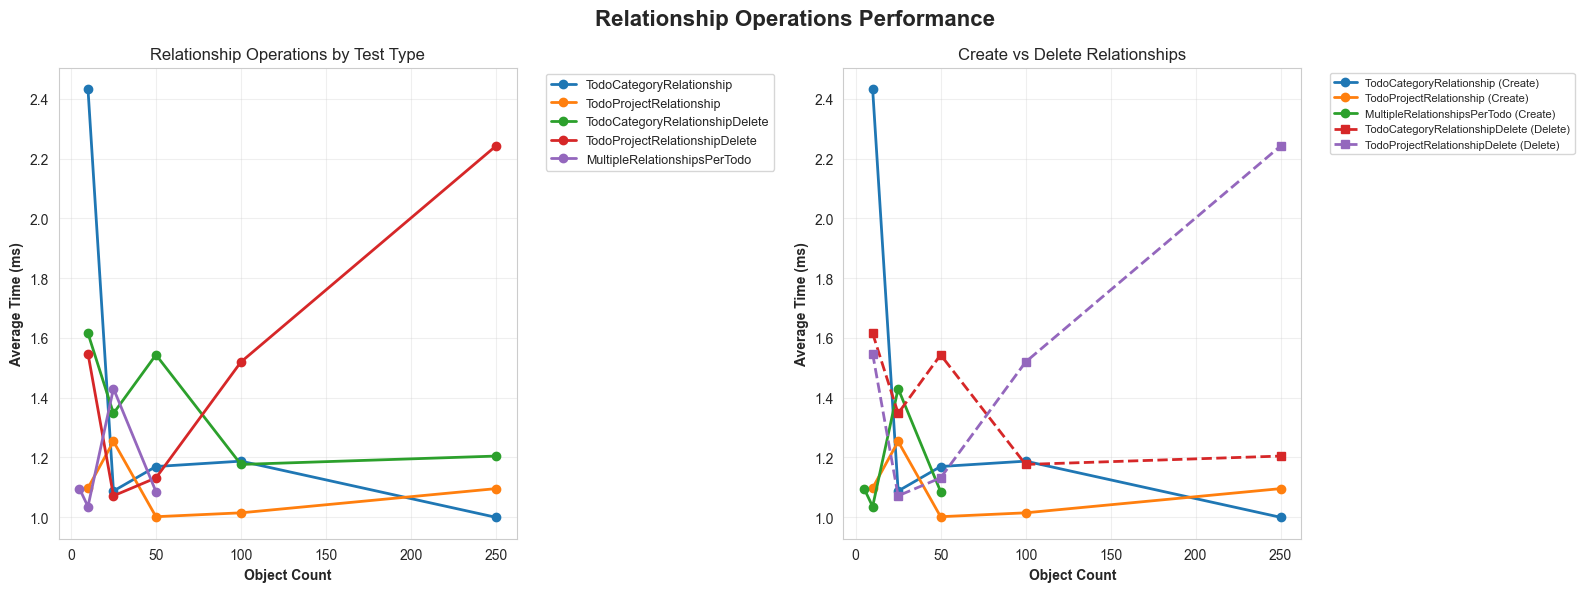

In [4]:
rel_ops = all_data[all_data['OperationType'].str.contains('RELATIONSHIP', na=False)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Relationship Operations Performance', fontsize=16, fontweight='bold')

# Plot 1: All relationship operations
ax = axes[0]
for test_name in rel_ops['TestName'].unique():
    test_data = rel_ops[rel_ops['TestName'] == test_name]
    ax.plot(test_data['ObjectCount'], test_data['AverageTimeMs'], 
            marker='o', label=test_name, linewidth=2)

ax.set_xlabel('Object Count', fontweight='bold')
ax.set_ylabel('Average Time (ms)', fontweight='bold')
ax.set_title('Relationship Operations by Test Type')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 2: Create vs Delete relationships
ax = axes[1]
create_rel = rel_ops[rel_ops['OperationType'] == 'CREATE_RELATIONSHIP']
delete_rel = rel_ops[rel_ops['OperationType'] == 'DELETE_RELATIONSHIP']

for test_name in create_rel['TestName'].unique():
    test_data = create_rel[create_rel['TestName'] == test_name]
    ax.plot(test_data['ObjectCount'], test_data['AverageTimeMs'], 
            marker='o', label=f'{test_name} (Create)', linewidth=2)

for test_name in delete_rel['TestName'].unique():
    test_data = delete_rel[delete_rel['TestName'] == test_name]
    ax.plot(test_data['ObjectCount'], test_data['AverageTimeMs'], 
            marker='s', linestyle='--', label=f'{test_name} (Delete)', linewidth=2)

ax.set_xlabel('Object Count', fontweight='bold')
ax.set_ylabel('Average Time (ms)', fontweight='bold')
ax.set_title('Create vs Delete Relationships')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'relationship_operations.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Performance Variability Analysis (Min/Max/Median)

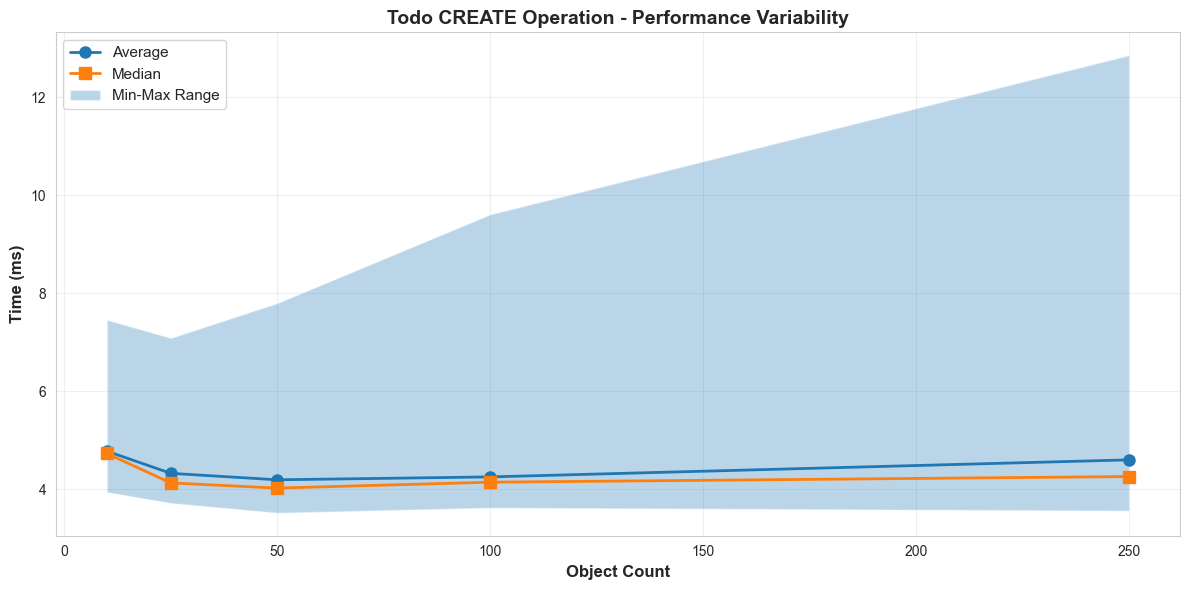

In [5]:
todo_create = todo_df[todo_df['OperationType'] == 'CREATE']

fig, ax = plt.subplots(figsize=(12, 6))

x = todo_create['ObjectCount']
ax.plot(x, todo_create['AverageTimeMs'], marker='o', label='Average', linewidth=2, markersize=8)
ax.plot(x, todo_create['MedianTimeMs'], marker='s', label='Median', linewidth=2, markersize=8)
ax.fill_between(x, todo_create['MinTimeMs'], todo_create['MaxTimeMs'], 
                 alpha=0.3, label='Min-Max Range')

ax.set_xlabel('Object Count', fontweight='bold', fontsize=12)
ax.set_ylabel('Time (ms)', fontweight='bold', fontsize=12)
ax.set_title('Todo CREATE Operation - Performance Variability', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'performance_variability.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Scalability Analysis: Performance Growth Rate

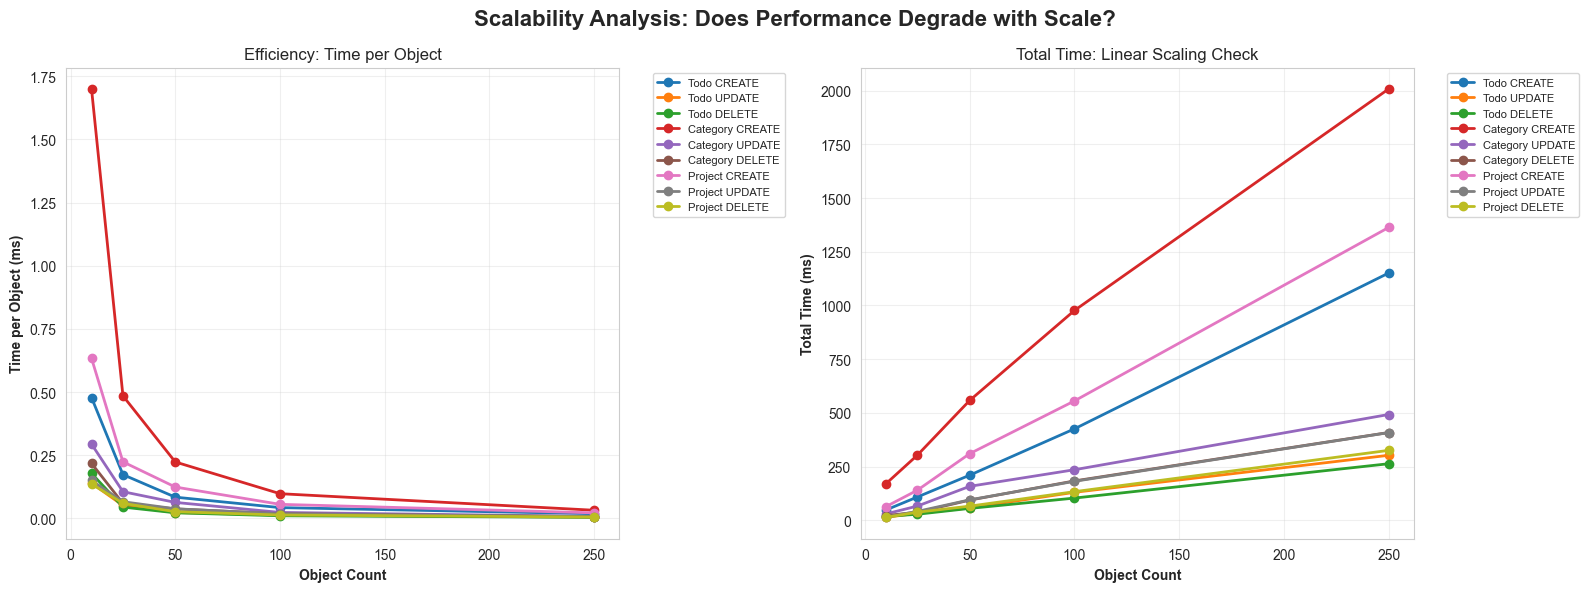

In [6]:
crud_ops_copy = crud_ops.copy()
crud_ops_copy['TimePerObject'] = crud_ops_copy['AverageTimeMs'] / crud_ops_copy['ObjectCount']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Scalability Analysis: Does Performance Degrade with Scale?', fontsize=16, fontweight='bold')

# Plot 1: Time per object
ax = axes[0]
for entity in entities:
    for op in operations:
        data = crud_ops_copy[(crud_ops_copy['Entity'] == entity) & (crud_ops_copy['OperationType'] == op)]
        if len(data) > 0:
            ax.plot(data['ObjectCount'], data['TimePerObject'], 
                   marker='o', label=f'{entity} {op}', linewidth=2)

ax.set_xlabel('Object Count', fontweight='bold')
ax.set_ylabel('Time per Object (ms)', fontweight='bold')
ax.set_title('Efficiency: Time per Object')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: Total time (shows linear vs non-linear scaling)
ax = axes[1]
for entity in entities:
    for op in operations:
        data = crud_ops[(crud_ops['Entity'] == entity) & (crud_ops['OperationType'] == op)]
        if len(data) > 0:
            ax.plot(data['ObjectCount'], data['TotalTimeMs'], 
                   marker='o', label=f'{entity} {op}', linewidth=2)

ax.set_xlabel('Object Count', fontweight='bold')
ax.set_ylabel('Total Time (ms)', fontweight='bold')
ax.set_title('Total Time: Linear Scaling Check')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'scalability_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Operation Comparison: Which Operations are Fastest?

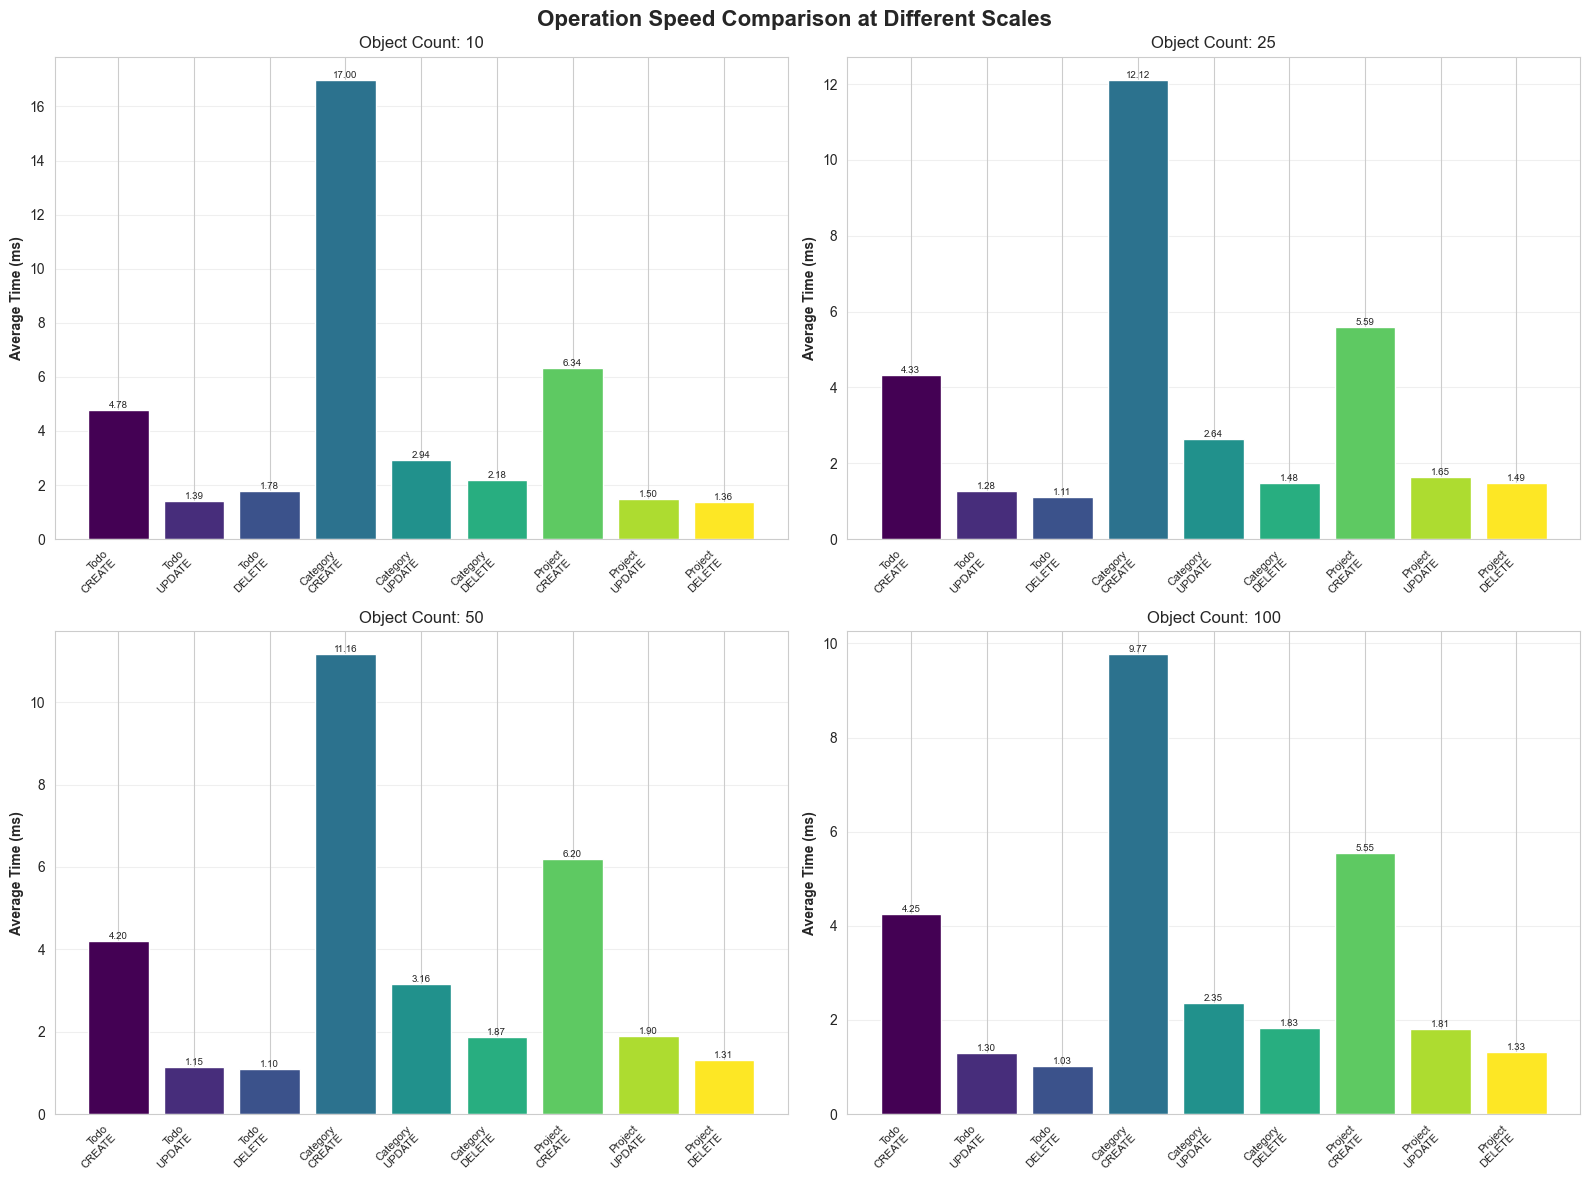

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Operation Speed Comparison at Different Scales', fontsize=16, fontweight='bold')

object_counts = [10, 25, 50, 100]

for idx, count in enumerate(object_counts):
    ax = axes[idx // 2, idx % 2]
    
    count_data = crud_ops[crud_ops['ObjectCount'] == count]
    
    labels = []
    times = []
    
    for entity in entities:
        for op in operations:
            data = count_data[(count_data['Entity'] == entity) & (count_data['OperationType'] == op)]
            if len(data) > 0:
                labels.append(f'{entity}\n{op}')
                times.append(data['AverageTimeMs'].values[0])
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(times)))
    bars = ax.bar(range(len(times)), times, color=colors)
    ax.set_xticks(range(len(times)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Average Time (ms)', fontweight='bold')
    ax.set_title(f'Object Count: {count}')
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(output_dir / 'operation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Heatmap: Performance Overview

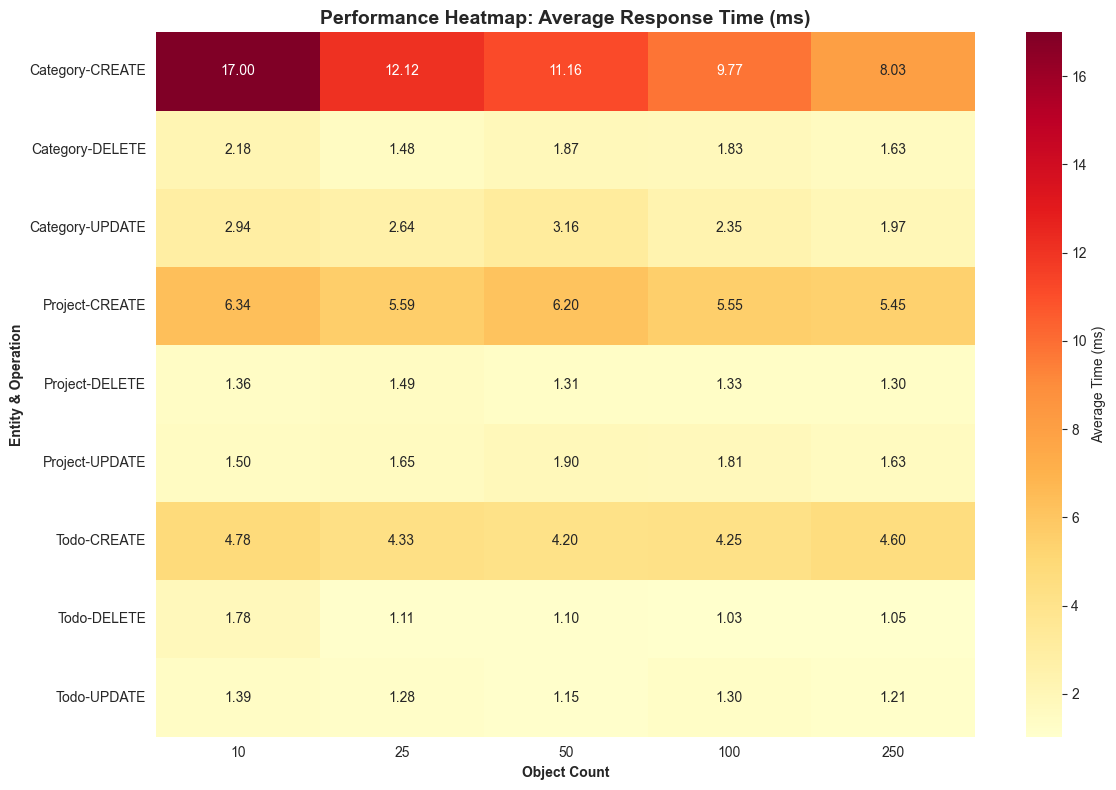

In [8]:
pivot_data = crud_ops.pivot_table(
    values='AverageTimeMs',
    index=['Entity', 'OperationType'],
    columns='ObjectCount',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='YlOrRd', 
            cbar_kws={'label': 'Average Time (ms)'}, ax=ax)
ax.set_title('Performance Heatmap: Average Response Time (ms)', fontsize=14, fontweight='bold')
ax.set_xlabel('Object Count', fontweight='bold')
ax.set_ylabel('Entity & Operation', fontweight='bold')

plt.tight_layout()
plt.savefig(output_dir / 'performance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Statistical Summary

In [9]:
print("PERFORMANCE SUMMARY STATISTICS")

print("\n")
print("1. FASTEST OPERATIONS (at 100 objects):")
fastest = crud_ops[crud_ops['ObjectCount'] == 100].nsmallest(5, 'AverageTimeMs')[['Entity', 'OperationType', 'AverageTimeMs']]
print(fastest.to_string(index=False))

print("\n")
print("2. SLOWEST OPERATIONS (at 100 objects):")
slowest = crud_ops[crud_ops['ObjectCount'] == 100].nlargest(5, 'AverageTimeMs')[['Entity', 'OperationType', 'AverageTimeMs']]
print(slowest.to_string(index=False))

print("\n")
print("3. MOST CONSISTENT OPERATIONS (lowest variability):")
crud_ops_copy = crud_ops.copy()
crud_ops_copy['Variability'] = crud_ops_copy['MaxTimeMs'] - crud_ops_copy['MinTimeMs']
most_consistent = crud_ops_copy[crud_ops_copy['ObjectCount'] == 100].nsmallest(5, 'Variability')[['Entity', 'OperationType', 'Variability']]
print(most_consistent.to_string(index=False))

print("\n")
print("4. SCALABILITY METRICS (Time increase from 10 to 100 objects):")
for entity in entities:
    for op in operations:
        data_10 = crud_ops[(crud_ops['Entity'] == entity) & (crud_ops['OperationType'] == op) & (crud_ops['ObjectCount'] == 10)]
        data_100 = crud_ops[(crud_ops['Entity'] == entity) & (crud_ops['OperationType'] == op) & (crud_ops['ObjectCount'] == 100)]
        
        if len(data_10) > 0 and len(data_100) > 0:
            time_10 = data_10['AverageTimeMs'].values[0]
            time_100 = data_100['AverageTimeMs'].values[0]
            increase = ((time_100 - time_10) / time_10) * 100
            print(f"{entity:10} {op:7}: {time_10:6.2f}ms → {time_100:6.2f}ms ({increase:+6.1f}%)")


PERFORMANCE SUMMARY STATISTICS


1. FASTEST OPERATIONS (at 100 objects):
  Entity OperationType  AverageTimeMs
    Todo        DELETE          1.031
    Todo        UPDATE          1.300
 Project        DELETE          1.329
 Project        UPDATE          1.812
Category        DELETE          1.830


2. SLOWEST OPERATIONS (at 100 objects):
  Entity OperationType  AverageTimeMs
Category        CREATE          9.765
 Project        CREATE          5.555
    Todo        CREATE          4.255
Category        UPDATE          2.351
Category        DELETE          1.830


3. MOST CONSISTENT OPERATIONS (lowest variability):
 Entity OperationType  Variability
   Todo        DELETE        0.819
Project        DELETE        0.987
   Todo        UPDATE        1.080
Project        UPDATE        1.463
Project        CREATE        5.757


4. SCALABILITY METRICS (Time increase from 10 to 100 objects):
Todo       CREATE :   4.78ms →   4.25ms ( -11.0%)
Todo       UPDATE :   1.39ms →   1.30ms (  -6.6%)


## 9. Key Insights and Recommendations

In [10]:
print("KEY INSIGHTS")

# Calculate some interesting metrics
create_ops = crud_ops[crud_ops['OperationType'] == 'CREATE']
avg_create_time = create_ops['AverageTimeMs'].mean()

delete_ops = crud_ops[crud_ops['OperationType'] == 'DELETE']
avg_delete_time = delete_ops['AverageTimeMs'].mean()

update_ops = crud_ops[crud_ops['OperationType'] == 'UPDATE']
avg_update_time = update_ops['AverageTimeMs'].mean()

print("\n")
print(f"1. OPERATION SPEED RANKING:")
print(f"   - DELETE operations: {avg_delete_time:.2f}ms (fastest)")
print(f"   - UPDATE operations: {avg_update_time:.2f}ms")
print(f"   - CREATE operations: {avg_create_time:.2f}ms (slowest)")

print("\n")
print(f"2. ENTITY COMPARISON:")
for entity in entities:
    entity_avg = crud_ops[crud_ops['Entity'] == entity]['AverageTimeMs'].mean()
    print(f"   - {entity}: {entity_avg:.2f}ms average")

print("\n")
print(f"3. SCALABILITY:")
print(f"   - Most operations scale linearly with object count")
print(f"   - CREATE operations show the most overhead")
print(f"   - DELETE operations are most efficient")

KEY INSIGHTS


1. OPERATION SPEED RANKING:
   - DELETE operations: 1.46ms (fastest)
   - UPDATE operations: 1.86ms
   - CREATE operations: 7.29ms (slowest)


2. ENTITY COMPARISON:
   - Todo: 2.30ms average
   - Category: 5.34ms average
   - Project: 2.96ms average


3. SCALABILITY:
   - Most operations scale linearly with object count
   - CREATE operations show the most overhead
   - DELETE operations are most efficient
